In [38]:
# import libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:
# read in data — CB07 used as the prediction target station
df = pd.read_csv('../../datasets/TxSON_data_2026-02-24/CB07.dat',
                 skiprows=5, parse_dates=['Date'], index_col='Date')

In [40]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [41]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [ ]:
# removes spaces in the column names and drops non-numeric Flag column
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ', '')
    df.drop(['Flag'], axis=1, inplace=True)
    for col in ['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50']:
        df[col] = df[col].astype(float)

In [43]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [44]:
# Verify shape of data frame
df.shape

(72, 10)

### Train/test split 

In [45]:
# split data into train and test
train_len = 60
test_len = 12
total_len = 72

train = df.SWC_5[:train_len]
test = df.SWC_5[train_len:]

test

Date
2020-01-31    0.176367
2020-02-29    0.198210
2020-03-31    0.199926
2020-04-30    0.172165
2020-05-31    0.161712
2020-06-30    0.119962
2020-07-31    0.089724
2020-08-31    0.084403
2020-09-30    0.186056
2020-10-31    0.101843
2020-11-30    0.103483
2020-12-31    0.143557
Freq: M, Name: SWC_5, dtype: float64

In [46]:
# incorperate exog data
exog = df.Ppt[:train_len]


### SARIMA(p,0,q)(P,0,Q)<sub>12<sub> 

In [47]:
# Define SARIMA model
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [48]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 365

In [49]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(train, exog, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), -100.66962687953809]
[(0, 1, 0, 0), -139.30169603628008]
[(1, 0, 0, 0), -249.29906221916673]
[(1, 1, 0, 0), -248.03670348801768]


,"(p,q,P,Q)",AIC
0,"(1, 0, 0, 0)",-249.299062
1,"(1, 1, 0, 0)",-248.036703
2,"(0, 1, 0, 0)",-139.301696
3,"(0, 0, 0, 0)",-100.669627


In [50]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(train, order=((SARIMA_result_df.iloc[0][0][0]), 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], 365), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  SWC_5   No. Observations:                   60
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 114.510
Date:                Fri, 04 Aug 2023   AIC                           -225.020
Time:                        12:47:52   BIC                           -220.865
Sample:                    01-31-2015   HQIC                          -223.398
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9659      0.039     24.983      0.000       0.890       1.042
sigma2         0.0012      0.000      4.886      0.000       0.001       0.002
Ljung-Box (L1) (Q):                   2.56   Jarque-

## Forecasting 

In [51]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'last_season':
        pred_last_season = []
        
        
        for i in range(train_len, total_len, window):
            last_season = df.SWC_5[i-window:i]
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.SWC_5[:i], order=(SARIMA_result_df.iloc[0][0][0], 0, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], 0, SARIMA_result_df.iloc[0][0][3], 365), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [52]:
pred_df = df[train_len:]

pred_df

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
Date,,,,,,,,,,
2020-01-31,0.074691,0.176367,0.150926,0.140007,0.110190,12.987997,13.229691,13.444274,14.462110,17.733871
2020-02-29,0.051379,0.198210,0.174287,0.163825,0.161282,11.964598,12.171322,12.350862,13.246681,100.045977
2020-03-31,0.105417,0.199926,0.176344,0.168164,0.177484,18.767796,18.702177,18.560538,18.051559,28.946237
2020-04-30,0.114264,0.172165,0.161336,0.158357,0.175725,22.342722,22.164403,21.914347,21.040681,6.400000
2020-05-31,0.209960,0.161712,0.148136,0.141695,0.133820,27.973790,27.767970,27.473065,26.201048,127.669355
2020-06-30,0.020431,0.119962,0.123360,0.120833,0.132532,31.723028,31.340944,30.886764,29.084389,34.133333
2020-07-31,0.012634,0.089724,0.098980,0.100411,0.104659,36.307809,35.781129,35.200847,32.732151,49.561828
2020-08-31,0.009207,0.084403,0.093173,0.096808,0.100655,36.365833,35.945175,35.450511,33.416223,66.521505
2020-09-30,0.198153,0.186056,0.163171,0.152028,0.149914,25.913972,26.172056,26.391444,27.196292,34.177778


In [53]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len / 3)

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
pred_df.last_season

Date
2020-01-31    0.102663
2020-02-29    0.148231
2020-03-31    0.185464
2020-04-30    0.127410
2020-05-31    0.176367
2020-06-30    0.198210
2020-07-31    0.199926
2020-08-31    0.172165
2020-09-30    0.161712
2020-10-31    0.119962
2020-11-30    0.089724
2020-12-31    0.084403
Freq: M, Name: last_season, dtype: float64

In [54]:
# Define SARIMA Prediction Dataframe
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df.SARIMA

Date
2020-01-31    0.123059
2020-02-29    0.118857
2020-03-31    0.114799
2020-04-30    0.110879
2020-05-31    0.167457
2020-06-30    0.162878
2020-07-31    0.158423
2020-08-31    0.154091
2020-09-30    0.081475
2020-10-31    0.078649
2020-11-30    0.075920
2020-12-31    0.073286
Freq: M, Name: SARIMA, dtype: float64

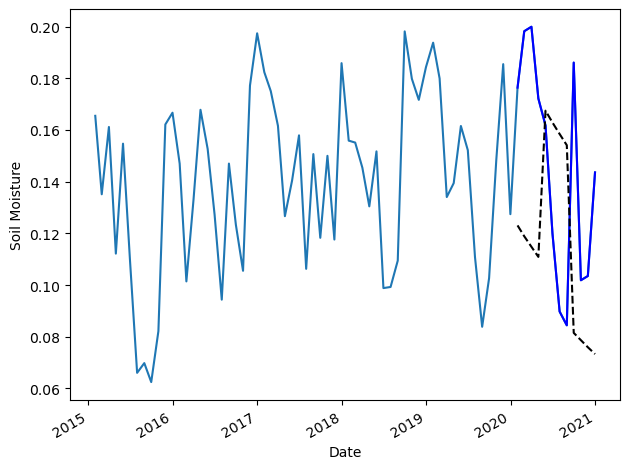

In [55]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(df.SWC_5)
ax.plot(pred_df.SWC_5, 'b-', label='actual')
#  ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Soil Moisture')

fig.autofmt_xdate()
plt.tight_layout()



## Evaluate 

In [56]:
mse=mean_squared_error(pred_df.SWC_5,pred_df.SARIMA)
mse

0.004063710863566425

In [57]:
pred_df.SWC_5

Date
2020-01-31    0.176367
2020-02-29    0.198210
2020-03-31    0.199926
2020-04-30    0.172165
2020-05-31    0.161712
2020-06-30    0.119962
2020-07-31    0.089724
2020-08-31    0.084403
2020-09-30    0.186056
2020-10-31    0.101843
2020-11-30    0.103483
2020-12-31    0.143557
Freq: M, Name: SWC_5, dtype: float64

In [58]:
pred_df.SARIMA

Date
2020-01-31    0.123059
2020-02-29    0.118857
2020-03-31    0.114799
2020-04-30    0.110879
2020-05-31    0.167457
2020-06-30    0.162878
2020-07-31    0.158423
2020-08-31    0.154091
2020-09-30    0.081475
2020-10-31    0.078649
2020-11-30    0.075920
2020-12-31    0.073286
Freq: M, Name: SARIMA, dtype: float64

## ARIMA Forecast

In [73]:
arima_order = (3, 0, 1) ## Even after optimization the ARIMA is not consistent with the SARIMAX or real
model = ARIMA(train, order=arima_order)
model_fit = model.fit()

In [74]:
checks = model_fit.forecast(steps=len(test))

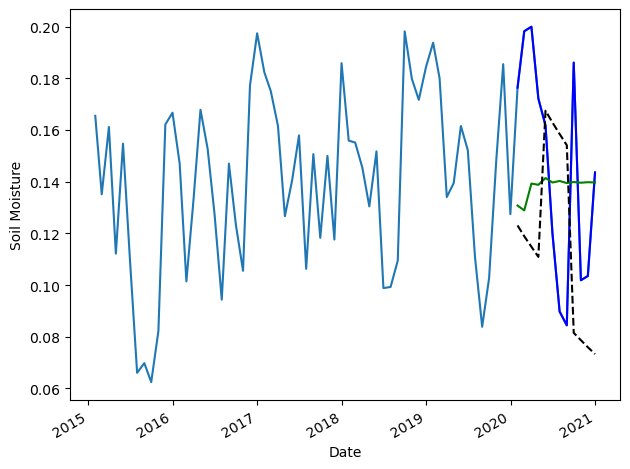

In [75]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(df.SWC_5)
ax.plot(pred_df.SWC_5, 'b-', label='actual')
ax.plot(checks, 'g-', label='ARIMA') ## Includes ARIMA
#  ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Soil Moisture')

fig.autofmt_xdate()
plt.tight_layout()

In [76]:
new_mse = mean_squared_error(pred_df.SWC_5,checks)
new_mse

0.0019134243321772418